## ML en Series Temporales: Gradient Boosting, XGBoost, LightGBM e Interpretabilidad con SHAP

### Universidad Autónoma de Occidente
### Maestría en Inteligencia Artificial y Ciencias de Datos

---

**Dataset:** Rossmann Store Sales — Tienda 746  
**Fuente:** [Kaggle Rossmann Store Sales](https://www.kaggle.com/c/rossmann-store-sales)  
**Objetivo:** Pronosticar ventas diarias incorporando variables exógenas (apertura, promociones) usando el ecosistema Nixtla.

---

### Mapa del Notebook

| Parte | Contenido |
|---|---|
| 1 | Instalación y configuración |
| 2 | Carga y exploración de datos |
| 3 | EDA: descomposición, ACF/PACF |
| 4 | Estacionariedad (ADF) |
| 5 | Feature engineering con `MLForecast.preprocess()` |
| 6 | Split train/test |
| 7 | Modelos base: LR, Ridge, Lasso, RF |
| 8 | Gradient Boosting: XGBoost y LightGBM |
| 9 | Cross-validation y benchmark completo |
| 10 | Pronósticos sobre test |
| 11 | Diagnóstico estadístico de residuos |
| 12 | SHAP: interpretabilidad con MLForecast |
| 13 | [Avanzado] AutoMLForecast + Optuna |


---
## PARTE 1: INSTALACIÓN Y CONFIGURACIÓN

In [2]:
!pip install -U mlforecast utilsforecast statsforecast --quiet
!pip install xgboost lightgbm shap --quiet
!pip install optuna --quiet  # solo para la Parte 13
!pip install jinja2 --quiet  

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# MLForecast — ecosistema Nixtla
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from mlforecast.lag_transforms import RollingMean, RollingStd, ExpandingMean
from utilsforecast.preprocessing import fill_gaps
from utilsforecast.feature_engineering import fourier
from utilsforecast.losses import mae, mape, rmse
from utilsforecast.evaluation import evaluate

# StatsForecast — benchmarks estadísticos (Semanas 1-2)
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, SeasonalNaive

# Modelos ML (sklearn-compatible)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Tests estadísticos
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tools import add_constant

# Visualización
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import shap
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✅ Librerías importadas correctamente')

/home/alejo/.virtualenvs/datascience-venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Librerías importadas correctamente


---
## PARTE 2: CARGA Y EXPLORACIÓN DE DATOS

**Dataset:** Rossmann Store Sales (Tienda 746)  
Una cadena alemana de farmacias. Pronosticar ventas es crítico para optimizar inventario y personal.  
La tienda 746 tiene variables exógenas relevantes: si está **abierta** (`Open`) y si hay **promoción activa** (`Promo`).

> **¿Por qué Rossmann para esta sesión?**  
> Los modelos estadísticos (ARIMA, ETS) modelan solo la serie `y`. Los modelos ML pueden incorporar `Open` y `Promo` de forma natural — esa es exactamente la ventaja que exploramos hoy.

In [4]:
!wget -q https://lazyprogrammer.me/course_files/timeseries/rossmann_train.csv

In [5]:
# Cargamos solo la tienda 746 y la preparamos en formato Nixtla: unique_id | ds | y
datos_raw = pd.read_csv('rossmann_train.csv', low_memory=False)
datos = (
    datos_raw
    .drop(columns=['DayOfWeek', 'Customers', 'StateHoliday', 'SchoolHoliday'])
    .query('Store == 746')
    .sort_values('Date')
    .reset_index(drop=True)
)
datos.columns = ['unique_id', 'ds', 'y', 'Open', 'Promo']
datos['ds'] = pd.to_datetime(datos['ds'])

# Rellenar días faltantes (días cerrados no están en el dataset)
datos = fill_gaps(datos, freq='D')
datos = datos.ffill()

display(datos.head(10))
print(f'\n📊 INFORMACIÓN DEL DATASET:')
print(f'  • Forma: {datos.shape}')
print(f'  • Período: {datos.ds.min().date()} → {datos.ds.max().date()}')
print(f'  • Duración: {(datos.ds.max() - datos.ds.min()).days} días')
print(f'  • Variable objetivo (ventas):')
print(f'      Media:  {datos.y.mean():.0f} EUR')
print(f'      Desv.:  {datos.y.std():.0f} EUR')
print(f'      Rango:  [{datos.y.min():.0f}, {datos.y.max():.0f}]')
print(f'      CV:     {datos.y.std()/datos.y.mean()*100:.1f}%')
print(f'  • Días con promoción: {datos.Promo.sum()} ({datos.Promo.mean()*100:.1f}%)')
print(f'  • Días abierto:       {datos.Open.sum()} ({datos.Open.mean()*100:.1f}%)')

,unique_id,ds,y,Open,Promo
0,746,2013-01-01,0,0,0
1,746,2013-01-02,4558,1,0
2,746,2013-01-03,3972,1,0
3,746,2013-01-04,4718,1,0
4,746,2013-01-05,4605,1,0
5,746,2013-01-06,0,0,0
6,746,2013-01-07,7338,1,1
7,746,2013-01-08,5257,1,1
8,746,2013-01-09,5755,1,1
9,746,2013-01-10,4778,1,1



📊 INFORMACIÓN DEL DATASET:
  • Forma: (942, 5)
  • Período: 2013-01-01 → 2015-07-31
  • Duración: 941 días
  • Variable objetivo (ventas):
      Media:  5007 EUR
      Desv.:  2791 EUR
      Rango:  [0, 13950]
      CV:     55.7%
  • Días con promoción: 360 (38.2%)
  • Días abierto:       781 (82.9%)


In [6]:
# Serie temporal con coloreado por promoción
promo_on  = datos[datos.Promo == 1]
promo_off = datos[datos.Promo == 0]

fig = go.Figure()
fig.add_trace(go.Scatter(x=datos.ds, y=datos.y, mode='lines',
                         name='Ventas', line=dict(color='#1f77b4', width=1)))
fig.add_trace(go.Scatter(x=promo_on.ds, y=promo_on.y, mode='markers',
                         name='Días con Promo', marker=dict(color='#e74c3c', size=3, opacity=0.5)))
fig.update_layout(
    title='Serie Temporal: Ventas Diarias — Rossmann Tienda 746',
    xaxis_title='Fecha', yaxis_title='Ventas (EUR)',
    hovermode='x unified', height=450, template='plotly_white'
)
fig.show()
print('💡 Observación: Los picos rojos (días con promoción) coinciden visiblemente con ventas altas.')
print('   Esto motiva incluir Promo como variable exógena en el modelo ML.')

💡 Observación: Los picos rojos (días con promoción) coinciden visiblemente con ventas altas.
   Esto motiva incluir Promo como variable exógena en el modelo ML.


---
## PARTE 3: EDA — DESCOMPOSICIÓN ESTACIONAL Y AUTOCORRELACIÓN

Antes de modelar, entendemos la estructura de la serie.  
**Recordatorio de Semana 1:** los spikes de ACF/PACF nos dicen qué lags usar.

In [7]:
# ACF y PACF — buscamos los lags significativos
n_lags = 30
acf_vals  = acf(datos.y, nlags=n_lags)
pacf_vals = pacf(datos.y, nlags=n_lags, method='ols')
conf_int  = 1.96 / np.sqrt(len(datos))

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('ACF — Autocorrelación', 'PACF — Autocorrelación Parcial'))
for i, (v, label, color) in enumerate([(acf_vals, 'ACF', 'blue'), (pacf_vals, 'PACF', 'green')]):
    for lag, val in enumerate(v):
        c = color if abs(val) > conf_int else 'gray'
        fig.add_trace(go.Bar(x=[lag], y=[val], marker_color=c, showlegend=False), row=1, col=i+1)
    fig.add_hline(y= conf_int, line_dash='dash', line_color='red', row=1, col=i+1)
    fig.add_hline(y=-conf_int, line_dash='dash', line_color='red', row=1, col=i+1)

fig.update_layout(height=380, title='ACF y PACF — Ventas Tienda 746', template='plotly_white')
fig.show()

# Lags significativos
sig_acf  = [i for i, v in enumerate(acf_vals[1:], 1)  if abs(v) > conf_int]
sig_pacf = [i for i, v in enumerate(pacf_vals[1:], 1) if abs(v) > conf_int]
print(f'📌 Lags significativos ACF:  {sig_acf[:10]}  → confirman estacionalidad semanal (lag 7)')
print(f'📌 Lags significativos PACF: {sig_pacf[:10]} → indican dependencia directa de días recientes')
# ── Justificación directa de la configuración de features ────────────────────────
# La PACF revela dependencia directa (sin intermediarios): usamos esos lags.
# Adicionalmente, el período estacional semanal (7) y sus múltiplos son relevantes.
lags_sugeridos = sorted(set(
    [l for l in sig_pacf[:6] if l <= 28]   # lags de PACF dentro de 1 mes
    + [7, 14, 28]                           # lags estacionales fijos
))
print(f'\n📐 Lags sugeridos por ACF/PACF + estacionalidad: {lags_sugeridos}')
print(f'   → En la celda de Feature Engineering usaremos: LAGS = {lags_sugeridos}')
print(f'   (Coincide con [1, 7, 14, 28] que es nuestro rango práctico para datos diarios)')


📌 Lags significativos ACF:  [2, 3, 5, 6, 7, 8, 9, 14, 15, 17]  → confirman estacionalidad semanal (lag 7)
📌 Lags significativos PACF: [2, 3, 5, 6, 7, 8, 9, 11, 12, 13] → indican dependencia directa de días recientes

📐 Lags sugeridos por ACF/PACF + estacionalidad: [2, 3, 5, 6, 7, 8, 14, 28]
   → En la celda de Feature Engineering usaremos: LAGS = [2, 3, 5, 6, 7, 8, 14, 28]
   (Coincide con [1, 7, 14, 28] que es nuestro rango práctico para datos diarios)


In [8]:
# Descomposición estacional — elegimos aditiva vs multiplicativa por varianza de residuos
#
# ⚠️  NOTA PEDAGÓGICA — Error común con datos reales:
#    La descomposición multiplicativa asume y_t > 0 en todos los puntos.
#    Rossmann tiene días con ventas = 0 (tienda cerrada) → ValueError si intentamos
#    aplicarla directamente. Solución: intentar multiplicativa y caer a aditiva si falla.
#    Este patrón es buena práctica con cualquier dataset que pueda tener ceros.

periodo = 7  # Rossmann: patrón semanal dominante

dec_add = seasonal_decompose(datos.y, model='additive', period=periodo, extrapolate_trend='freq')
var_add = np.var(dec_add.resid.dropna())

try:
    # La multiplicativa requiere y_t > 0 estrictamente.
    # Con Rossmann falla porque hay días de cierre (y=0).
    if (datos.y <= 0).any():
        raise ValueError(
            f'Serie contiene {(datos.y <= 0).sum()} valores <= 0 '
            f'(días cerrados). Descomposición multiplicativa no aplicable.'
        )
    dec_mul  = seasonal_decompose(datos.y, model='multiplicative', period=periodo, extrapolate_trend='freq')
    var_mul  = np.var(dec_mul.resid.dropna())
    mejor    = 'aditivo' if var_add < var_mul else 'multiplicativo'
    dec      = dec_add if mejor == 'aditivo' else dec_mul
    print(f'• Varianza residuos aditivo:        {var_add:.2f}')
    print(f'• Varianza residuos multiplicativo: {var_mul:.2f}')
    print(f'→ Mejor modelo: {mejor.upper()}')
except ValueError as e:
    # Caída controlada: informamos al estudiante exactamente qué pasó y por qué
    print(f'⚠️  Descomposición multiplicativa descartada:')
    print(f'   {e}')
    print(f'   → Usando modelo ADITIVO (único viable con ceros en la serie).')
    mejor = 'aditivo'
    dec   = dec_add

print(f'\n📊 Análisis cuantitativo — modelo {mejor.upper()}:')
print(f'  • Fuerza de tendencia:    {np.std(dec.trend.dropna())/np.std(dec.observed):.3f}')
print(f'  • Fuerza estacional:      {np.std(dec.seasonal.dropna())/np.std(dec.observed):.3f}')
print(f'  • Amplitud estacional:    {dec.seasonal.max()-dec.seasonal.min():.0f}')
print(f'  • Ruido residual (ratio): {np.std(dec.resid.dropna())/np.std(dec.observed):.3f}')

fig = make_subplots(rows=4, cols=1, vertical_spacing=0.05,
                    subplot_titles=('Serie original', 'Tendencia', 'Estacionalidad', 'Residuos'))
componentes = [('observed', 'blue'), ('trend', 'red'), ('seasonal', 'green'), ('resid', 'orange')]
for row, (comp, color) in enumerate(componentes, 1):
    fig.add_trace(go.Scatter(x=datos.ds, y=getattr(dec, comp),
                             mode='lines', showlegend=False,
                             line=dict(color=color, width=1)), row=row, col=1)
fig.update_layout(height=800,
                  title=f'Descomposición Estacional — Modelo {mejor.upper()}',
                  template='plotly_white')
fig.show()


⚠️  Descomposición multiplicativa descartada:
   Serie contiene 161 valores <= 0 (días cerrados). Descomposición multiplicativa no aplicable.
   → Usando modelo ADITIVO (único viable con ceros en la serie).

📊 Análisis cuantitativo — modelo ADITIVO:
  • Fuerza de tendencia:    0.393
  • Fuerza estacional:      0.746
  • Amplitud estacional:    6775
  • Ruido residual (ratio): 0.475


---
## PARTE 4: ANÁLISIS DE ESTACIONARIEDAD

Aplicamos la prueba ADF antes y después de la transformación por diferencias.  
**MLForecast** puede aplicar estas transformaciones automáticamente con `target_transforms`.

In [9]:
def adf_report(series, nombre):
    res = adfuller(series.dropna(), autolag='AIC')
    estacionaria = res[1] <= 0.05
    icono = '✅ ESTACIONARIA' if estacionaria else '❌ NO ESTACIONARIA'
    print(f'ADF — {nombre}:')
    print(f'  Estadístico: {res[0]:.4f}  |  p-valor: {res[1]:.4f}  →  {icono}')
    return estacionaria

adf_report(datos.y, 'Serie original')

# Diferencia de orden 7 (elimina estacionalidad semanal)
datos_diff7 = datos.y.diff(7)
adf_report(datos_diff7, 'Diff(7) — diferencia semanal')

print('\n💡 La diferencia semanal Diff(7) se aplica vía target_transforms=[Differences([7])]')
print('   en el objeto MLForecast — sin necesidad de modificar el DataFrame original.')

ADF — Serie original:
  Estadístico: -3.3988  |  p-valor: 0.0110  →  ✅ ESTACIONARIA
ADF — Diff(7) — diferencia semanal:
  Estadístico: -12.7432  |  p-valor: 0.0000  →  ✅ ESTACIONARIA

💡 La diferencia semanal Diff(7) se aplica vía target_transforms=[Differences([7])]
   en el objeto MLForecast — sin necesidad de modificar el DataFrame original.


In [10]:
# Visualizar el efecto de distintas diferenciaciones usando MLForecast.preprocess()
def plot_differences(df, differences, freq='D'):
    prep_list = [df.assign(unique_id='original')]
    for d in differences:
        fcst_ = MLForecast(models=[], freq=freq, target_transforms=[Differences([d])])
        df_   = fcst_.preprocess(df.copy())
        df_['unique_id'] = f'diff({d})'
        prep_list.append(df_)
    prep = pd.concat(prep_list, ignore_index=True)

    fig = go.Figure()
    for uid in prep.unique_id.unique():
        sub = prep[prep.unique_id == uid]
        fig.add_trace(go.Scatter(x=sub.ds, y=sub.y, mode='lines', name=uid))
    fig.update_layout(title='Efecto de diferenciaciones sobre la serie',
                      xaxis_title='Fecha', yaxis_title='Valor transformado',
                      template='plotly_white', height=450)
    fig.show()

plot_differences(datos[['unique_id', 'ds', 'y']], differences=[1, 7, 28], freq='D')

---
## PARTE 5: FEATURE ENGINEERING CON `MLForecast.preprocess()`

**Concepto clave de la Sesión 1:** un modelo ML no entiende secuencias — necesita columnas.  
Aquí usamos `MLForecast.preprocess()` para ver exactamente qué features construye automáticamente.

> Esto es lo que el modelo realmente ve cuando entrenamos.

In [11]:
# Definimos la configuración de features — usada por TODOS los modelos en este notebook
FREQ  = 'D'
LAGS  = [1, 7, 14, 28]            # justificados por los spikes de PACF
LAG_TR = {
    1:  [RollingMean(window_size=7),   # tendencia local
         RollingStd(window_size=7)],   # volatilidad local
    7:  [RollingMean(window_size=28)], # tendencia mensual
    28: [ExpandingMean()],             # tendencia histórica acumulada
}
TGTTR = [Differences([7])]         # eliminar estacionalidad semanal

# ── Términos de Fourier: reemplazan 'dayofweek' ───────────────────────────────────────────
# ¿Por qué Fourier en lugar de dayofweek ordinal?
#   dayofweek: lunes=0 … domingo=6 → el modelo percibe domingo (6) lejos de lunes (0)
#   cuando en realidad son adyacentes. Encoding ordinal rompe la continuidad cíclica.
#
#   Fourier proyecta el ciclo semanal en un círculo unitario con pares sin/cos.
#   k=2 → 2 armónicos → 4 columnas: sin1_7, cos1_7, sin2_7, cos2_7.
#   fourier() retorna (df_histórico, df_futuro_extra).
#   Usamos SOLO el histórico: nuestro test set ya está dentro de datos_f
#   porque fue recortado de él — no necesitamos proyección futura.
# h=1: mínimo requerido por la API; el segundo retorno se descarta con _.
HORIZONTE = 30

datos_f, _ = fourier(
    datos,
    freq='D',
    season_length=7,   # estacionalidad semanal
    k=2,               # 2 pares sin/cos → sin1_7, cos1_7, sin2_7, cos2_7
    h=1,               # mínimo requerido
)
FOURIER_COLS = [c for c in datos_f.columns if c not in datos.columns]
print(f'✅ Términos de Fourier generados: {FOURIER_COLS}')
print(f'   datos_f shape:  {datos_f.shape}  (histórico con Fourier)')

# DATE_F solo contiene 'month'; el día de semana está cubierto por Fourier
DATE_F = ['month']

# Instanciamos MLForecast sin modelos solo para inspeccionar los features
# IMPORTANTE: static_features=[] porque Fourier cambia en cada período (es dinámico)
fcst_explorer = MLForecast(
    models=[],
    freq=FREQ,
    lags=LAGS,
    lag_transforms=LAG_TR,
    date_features=DATE_F,
    target_transforms=TGTTR,
)

features_df = fcst_explorer.preprocess(
    datos_f[['unique_id', 'ds', 'y'] + FOURIER_COLS],
    static_features=[]   # Fourier es dinámico: cambia cada día
)
print(f'\nDimensiones del dataset de features: {features_df.shape}')
print(f'Columnas generadas:')
feature_cols = [c for c in features_df.columns if c not in ['unique_id','ds','y']]
for c in feature_cols:
    print(f'  • {c}')
display(features_df.tail(5))


✅ Términos de Fourier generados: ['sin1_7', 'sin2_7', 'cos1_7', 'cos2_7']
   datos_f shape:  (942, 9)  (histórico con Fourier)

Dimensiones del dataset de features: (901, 16)
Columnas generadas:
  • sin1_7
  • sin2_7
  • cos1_7
  • cos2_7
  • lag1
  • lag7
  • lag14
  • lag28
  • rolling_mean_lag1_window_size7
  • rolling_std_lag1_window_size7
  • rolling_mean_lag7_window_size28
  • expanding_mean_lag28
  • month


,unique_id,ds,y,sin1_7,sin2_7,cos1_7,cos2_7,lag1,lag7,lag14,lag28,rolling_mean_lag1_window_size7,rolling_std_lag1_window_size7,rolling_mean_lag7_window_size28,expanding_mean_lag28,month
937,746,2015-07-27,4723.0,0.000007,0.000014,1.000000,1.000000,0.0,-4656.0,4747.0,4766.0,-1943.142822,1563.819092,-41.571430,10.869325,7
938,746,2015-07-28,4113.0,0.781827,0.974931,0.623496,-0.222506,4723.0,-2420.0,2731.0,3304.0,-603.285706,2555.534180,-14.428572,14.512168,7
939,746,2015-07-29,2311.0,0.974933,-0.433843,-0.222499,-0.900988,4113.0,-2297.0,1046.0,3847.0,330.000000,2944.777344,23.464285,18.746962,7
940,746,2015-07-30,2000.0,0.433863,-0.781802,-0.900979,0.623527,2311.0,-2298.0,1875.0,2093.0,988.285706,2769.480469,45.000000,21.036425,7
941,746,2015-07-31,3495.0,-0.433892,0.781842,-0.900965,0.623476,2000.0,-1723.0,580.0,1971.0,1602.285767,2366.610107,86.428574,23.186329,7


In [12]:
# Mapa de correlaciones entre features y target
corr = features_df[feature_cols + ['y']].corr()['y'].drop('y').sort_values(key=abs, ascending=False)

fig = go.Figure(go.Bar(
    x=corr.values, y=corr.index, orientation='h',
    marker_color=['#e74c3c' if v < 0 else '#2ecc71' for v in corr.values]
))
fig.update_layout(
    title='Correlación de Features con el Target (ventas)',
    xaxis_title='Correlación de Pearson', yaxis_title='Feature',
    height=420, template='plotly_white'
)
fig.show()
print('💡 Los lags con mayor correlación serán los más importantes en los modelos de boosting.')

💡 Los lags con mayor correlación serán los más importantes en los modelos de boosting.


---
## PARTE 6: SPLIT TRAIN / TEST

Usamos los últimos 30 días como test — sin tocarlos hasta la evaluación final.  
La validación de hiperparámetros siempre ocurre dentro del set de entrenamiento.

In [13]:
# HORIZONTE ya definido en celda anterior (al generar Fourier)
cutoff_dt = datos_f.ds.max() - pd.Timedelta(days=HORIZONTE)

df_train = datos_f[datos_f.ds <= cutoff_dt].copy()
df_test  = datos_f[datos_f.ds >  cutoff_dt].copy()

print(f'📅 Fecha de corte:   {cutoff_dt.date()}')
print(f'   Train: {df_train.ds.min().date()} → {df_train.ds.max().date()}  ({len(df_train)} días)')
print(f'   Test:  {df_test.ds.min().date()}  → {df_test.ds.max().date()}   ({len(df_test)} días)')
print(f'   Columnas Fourier en train/test: {FOURIER_COLS}')

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_train.ds, y=df_train.y, name='Train', line=dict(color='#2980b9')))
fig.add_trace(go.Scatter(x=df_test.ds,  y=df_test.y,  name='Test',  line=dict(color='#e74c3c')))
fig.add_shape(type='line',
              x0=cutoff_dt, x1=cutoff_dt,
              y0=0, y1=1, yref='paper',
              line=dict(color='gray', dash='dash'))
fig.add_annotation(x=cutoff_dt, y=1, yref='paper',
                   text='corte', showarrow=False, yshift=10)
fig.update_layout(title='Train / Test Split', xaxis_title='Fecha',
                  yaxis_title='Ventas (EUR)', template='plotly_white', height=380)
fig.show()


📅 Fecha de corte:   2015-07-01
   Train: 2013-01-01 → 2015-07-01  (912 días)
   Test:  2015-07-02  → 2015-07-31   (30 días)
   Columnas Fourier en train/test: ['sin1_7', 'sin2_7', 'cos1_7', 'cos2_7']


---
## PARTE 7: MODELOS BASE CON MLFORECAST

Seguimos la filosofía del curso: **empezar simple, construir hacia la complejidad**.  
Estos modelos son la referencia contra la que mediremos el boosting.

También incluimos `SeasonalNaive` y `AutoETS` de StatsForecast como benchmark de semanas anteriores.

In [14]:
# ── ¿Por qué static_features=[] en fit() y cross_validation()? ──────────────────────────
# MLForecast distingue entre features ESTÁTICAS (no cambian en el tiempo, ej: categoría de
# tienda) y DINÁMICAS (cambian en cada período, ej: Open, Promo).
# Por defecto intenta inferirlo; como Open y Promo cambian día a día, lanza ValueError.
# Solución: declarar static_features=[] → todas las columnas extra son dinámicas.
# Las variables dinámicas futuras se pasan vía X_df en predict().

modelos_base = {
    'lin_reg': LinearRegression(),
    'ridge':   Ridge(alpha=1.0),
    'lasso':   Lasso(alpha=0.1),
    'rf':      RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

# Nota: el baseline SeasonalNaive(season_length=7) ya está incluido en la sección
# de StatsForecast (celda siguiente) — no hace falta duplicarlo con una clase custom.

fcst_base = MLForecast(
    models=modelos_base,
    freq=FREQ,
    lags=LAGS,
    lag_transforms=LAG_TR,
    date_features=DATE_F,
    target_transforms=TGTTR,
)
print('✅ MLForecast con modelos base configurado')
print(f'   Modelos: {list(modelos_base.keys())}')
print(f'   Features: {LAGS} lags + lag_transforms + {DATE_F}')
print(f'   Exógenas dinámicas: Open, Promo (static_features=[])')


✅ MLForecast con modelos base configurado
   Modelos: ['lin_reg', 'ridge', 'lasso', 'rf']
   Features: [1, 7, 14, 28] lags + lag_transforms + ['month']
   Exógenas dinámicas: Open, Promo (static_features=[])


In [15]:
# static_features=[] le dice a MLForecast que Open y Promo son features DINÁMICAS
# (su valor es conocido en cada período futuro y se pasa vía X_df en predict)
cv_base = fcst_base.cross_validation(
    df=df_train,
    h=7,
    n_windows=5,
    step_size=7,
    refit=False,
    static_features=[],
)
print(f'CV base completado. Shape: {cv_base.shape}')
display(cv_base)


CV base completado. Shape: (35, 8)


,unique_id,ds,cutoff,y,lin_reg,ridge,lasso,rf
0,746,2015-05-28,2015-05-27,6190,3194.523682,3192.652344,3194.485840,4545.110352
1,746,2015-05-29,2015-05-27,7020,4883.520996,4892.391602,4884.178223,5912.390137
2,746,2015-05-30,2015-05-27,8358,7343.441406,7312.386719,7341.991211,6831.459961
3,746,2015-05-31,2015-05-27,0,-724.747314,-720.919006,-724.795532,0.000000
4,746,2015-06-01,2015-05-27,9190,7133.578613,7110.045410,7132.520020,6954.240234
5,746,2015-06-02,2015-05-27,8542,6939.688965,6955.190918,6940.378906,8758.500000
6,746,2015-06-03,2015-05-27,9736,8308.060547,8286.051758,8307.089844,8068.820312
7,746,2015-06-04,2015-06-03,0,3303.252686,3343.525635,3305.312256,2578.370117
8,746,2015-06-05,2015-06-03,8977,8789.419922,8770.546875,8788.952148,8697.019531
9,746,2015-06-06,2015-06-03,6510,7386.766113,7370.180664,7385.808105,7459.709961


In [16]:
# Benchmark estadístico: SeasonalNaive + AutoETS de StatsForecast
sf = StatsForecast(
    models=[SeasonalNaive(season_length=7), AutoETS(season_length=7)],
    freq='D', n_jobs=-1
)
cv_stats = sf.cross_validation(
    df=df_train,
    h=7, n_windows=5, step_size=7
)
print(f'CV estadísticos completado. Shape: {cv_stats.shape}')

CV estadísticos completado. Shape: (35, 6)


In [17]:
# Función de evaluación por folds con gradiente de color
def evaluate_cv(cv_df, metrics):
    """Evalúa cross-validation por fold y promedia. Retorna DataFrame estilizado."""
    model_cols = [c for c in cv_df.columns if c not in ['unique_id','ds','cutoff','y']]
    evals = []
    for cutoff in cv_df.cutoff.unique():
        sub = cv_df[cv_df.cutoff == cutoff]
        ev  = evaluate(sub, metrics=metrics, models=model_cols)
        evals.append(ev)
    result = (
        pd.concat(evals, ignore_index=True)
        .drop(columns='unique_id', errors='ignore')
        .groupby('metric', as_index=False)
        .mean()
    )
    return result.style.background_gradient(cmap='RdYlGn_r', axis=1)

METRICAS = [mae, rmse, mape]

# Merge de resultados ML + estadísticos
cv_todos = cv_base.merge(
    cv_stats.drop(columns=['y']),
    on=['unique_id', 'ds', 'cutoff'], how='left'
)

print('📊 Evaluación Cross-Validation — Modelos Base + Estadísticos:')
evaluate_cv(cv_todos, METRICAS)

📊 Evaluación Cross-Validation — Modelos Base + Estadísticos:


,metric,cutoff,lin_reg,ridge,lasso,rf,SeasonalNaive,AutoETS
0,mae,2015-06-10 00:00:00,1334.681409,1336.272653,1334.768009,992.277358,2710.600000,1549.414026
1,mape,2015-06-10 00:00:00,0.204525,0.204650,0.204525,0.169296,0.463846,0.216951
2,rmse,2015-06-10 00:00:00,1580.532145,1583.141838,1580.643213,1269.268673,3520.500178,1976.174954


---
## PARTE 8: GRADIENT BOOSTING — XGBOOST Y LIGHTGBM

**Recordatorio del slide:**  
- **Bagging (RF):** árboles *paralelos* e independientes, bootstrap i.i.d.
- **Boosting (XGBoost/LightGBM):** árboles *secuenciales*, cada uno aprende los **residuos** del anterior.

XGBoost agrega regularización explícita ($\gamma, \lambda, \alpha$) sobre la función de ganancia.  
LightGBM usa crecimiento **leaf-wise** + GOSS + EFB para escalar a series largas.

Ambos modelos son `sklearn`-compatible → se integran directamente en `MLForecast`.

In [18]:
xgb_model = XGBRegressor(
    # Parámetros de árbol
    max_depth          = 5,     # profundidad moderada — ver slide de hiperparámetros
    # Learning rate
    learning_rate      = 0.03,  # eta bajo + más iteraciones = más preciso
    n_estimators       = 600,   # usar con early stopping en producción
    # Submuestreo — reduce varianza temporal
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    # Regularización — clave en ST para no memorizar ruido
    reg_lambda         = 1.5,   # L2: shrinkage de pesos de hojas
    reg_alpha          = 0.1,   # L1: sparsidad en pesos
    gamma              = 1.0,   # ganancia mínima para un split
    min_child_weight   = 3,     # evita hojas con pocas observaciones
    objective          = 'reg:squarederror',
    random_state       = 42,
    n_jobs             = -1,
)

lgbm_model = LGBMRegressor(
    # Parámetros leaf-wise
    num_leaves         = 31,    # controla la complejidad del árbol (leaf-wise)
    max_depth          = -1,    # sin límite de profundidad — controlado por num_leaves
    # Learning rate
    learning_rate      = 0.03,  # más bajo que XGBoost — leaf-wise converge más rápido
    n_estimators       = 500,
    # Submuestreo (GOSS ya hace algo similar internamente)
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    # Regularización — más agresiva que XGBoost para compensar leaf-wise
    reg_lambda         = 2.0,   # L2 fuerte
    reg_alpha          = 0.1,
    min_child_samples  = 20,    # equivalente a min_child_weight en XGBoost
    random_state       = 42,
    n_jobs             = -1,
    verbose            = -1,    # silenciar output de entrenamiento
)

print('✅ XGBRegressor y LGBMRegressor configurados')

✅ XGBRegressor y LGBMRegressor configurados


In [19]:
# NOTA: incluimos las variables exógenas Open y Promo
# MLForecast las pasa automáticamente al modelo si están en el DataFrame
fcst_boost = MLForecast(
    models={
        'xgb':  xgb_model,
        'lgbm': lgbm_model,
    },
    freq=FREQ,
    lags=LAGS,
    lag_transforms=LAG_TR,
    date_features=DATE_F,
    target_transforms=TGTTR,
)

fcst_boost.fit(df=df_train, static_features=[])
print('✅ Modelos de boosting entrenados con datos de train')
print(f'   Exógenas usadas: Open, Promo')

✅ Modelos de boosting entrenados con datos de train
   Exógenas usadas: Open, Promo


---
## PARTE 9: CROSS-VALIDATION Y BENCHMARK COMPLETO

Comparamos todos los modelos bajo el mismo protocolo de validación temporal.

In [20]:
cv_boost = fcst_boost.cross_validation(
    df=df_train,
    h=7,
    n_windows=5,
    step_size=7,
    refit=False,
    static_features=[],
)
print(f'CV boosting completado. Shape: {cv_boost.shape}')

CV boosting completado. Shape: (35, 6)


In [21]:
# Merge de todos los modelos para comparativa unificada
cv_completo = (
    cv_base
    .merge(cv_boost.drop(columns='y'), on=['unique_id','ds','cutoff'], how='left')
    .merge(cv_stats.drop(columns='y'), on=['unique_id','ds','cutoff'], how='left')
)

print('📊 Benchmark completo — Cross-Validation:')
evaluate_cv(cv_completo, METRICAS)

📊 Benchmark completo — Cross-Validation:


,metric,cutoff,lin_reg,ridge,lasso,rf,xgb,lgbm,SeasonalNaive,AutoETS
0,mae,2015-06-10 00:00:00,1334.681409,1336.272653,1334.768009,992.277358,940.498756,930.700831,2710.600000,1549.414026
1,mape,2015-06-10 00:00:00,0.204525,0.204650,0.204525,0.169296,0.154279,0.157629,0.463846,0.216951
2,rmse,2015-06-10 00:00:00,1580.532145,1583.141838,1580.643213,1269.268673,1173.369066,1157.590132,3520.500178,1976.174954


In [22]:
# Visualización de predicciones CV con marcas de corte por fold
modelos_plot = ['y', 'lin_reg', 'rf', 'xgb', 'lgbm', 'AutoETS']
colores      = ['#000000', '#e74c3c', '#9b59b6', '#e67e22', '#27ae60', '#3498db']

fig = go.Figure()
for col, color in zip(modelos_plot, colores):
    if col not in cv_completo.columns:
        continue
    ancho = 3 if col == 'y' else 1.5
    fig.add_trace(go.Scatter(
        x=cv_completo.ds, y=cv_completo[col],
        mode='lines', name=col,
        line=dict(color=color, width=ancho)
    ))

# Marcar cada cutoff de fold con add_shape (evita bug de add_vline con Timestamps)
cutoffs = sorted(cv_completo.cutoff.unique())
for k, ct in enumerate(cutoffs):
    fig.add_shape(
        type='line', x0=ct, x1=ct, y0=0, y1=1, yref='paper',
        line=dict(color='rgba(100,100,100,0.35)', dash='dot', width=1)
    )
    fig.add_annotation(
        x=ct, y=1.02, yref='paper',
        text=f'F{k+1}', showarrow=False, font=dict(size=9, color='gray')
    )

fig.update_layout(
    title='Cross-Validation — Predicciones por modelo (F1…F5: cortes de fold)',
    xaxis_title='Fecha', yaxis_title='Ventas (EUR)',
    hovermode='x unified', height=480, template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=-0.25, xanchor='center', x=0.5)
)
fig.show()
print(f'💡 Las líneas F1…F{len(cutoffs)} marcan los cortes de cada fold de CV.')
print(f'   Train crece hacia la derecha; cada Test (h=7) sigue inmediatamente al corte.')


💡 Las líneas F1…F5 marcan los cortes de cada fold de CV.
   Train crece hacia la derecha; cada Test (h=7) sigue inmediatamente al corte.


---
## PARTE 10: PRONÓSTICOS SOBRE DATOS DE TEST

Entrenamos con todo el train y predecimos el horizonte de 30 días.  
Pasamos las variables exógenas futuras (`Open`, `Promo`) conocidas en `X_df`.

In [23]:
# Re-entrenamos con todo df_train para el pronóstico final
fcst_base.fit(df=df_train,  static_features=[])
fcst_boost.fit(df=df_train, static_features=[])

# X_df para predict:
# df_test YA contiene las columnas Fourier (viene de datos_f).
# No hay que calcular nada extra — solo seleccionar las columnas exógenas.
X_test_exo = df_test[['unique_id', 'ds', 'Open', 'Promo'] + FOURIER_COLS]

preds_base  = fcst_base.predict( h=HORIZONTE, X_df=X_test_exo)
preds_boost = fcst_boost.predict(h=HORIZONTE, X_df=X_test_exo)

# Pronósticos estadísticos (SeasonalNaive y AutoETS no usan exógenas)
sf_final = StatsForecast(
    models=[SeasonalNaive(season_length=7), AutoETS(season_length=7)],
    freq='D', n_jobs=-1
)
sf_final.fit(df=df_train)
preds_stats = sf_final.predict(h=HORIZONTE)

# Consolidar resultados
test_results = (
    df_test
    .merge(preds_base,  on=['unique_id','ds'], how='left')
    .merge(preds_boost, on=['unique_id','ds'], how='left')
    .merge(preds_stats, on=['unique_id','ds'], how='left')
)
pred_cols = [c for c in test_results.columns
             if c not in ['unique_id','ds','y','Open','Promo'] + FOURIER_COLS]
test_results[pred_cols] = test_results[pred_cols].clip(lower=0)
print(f'✅ Pronósticos generados. Modelos: {pred_cols}')


✅ Pronósticos generados. Modelos: ['lin_reg', 'ridge', 'lasso', 'rf', 'xgb', 'lgbm', 'SeasonalNaive', 'AutoETS']


In [24]:
# Evaluación sobre test
eval_test = evaluate(
    df=test_results,
    models=pred_cols,
    metrics=METRICAS,
    target_col='y'
)
print('📊 Evaluación sobre datos de Test:')
display(eval_test.style.background_gradient(cmap='RdYlGn_r', axis=1))

📊 Evaluación sobre datos de Test:


,unique_id,metric,lin_reg,ridge,lasso,rf,xgb,lgbm,SeasonalNaive,AutoETS
0,746,mae,789.749080,777.414006,789.072282,575.724290,645.356673,660.828288,1578.200000,1103.748078
1,746,rmse,1094.162319,1079.486983,1093.360874,705.337657,816.226309,915.917925,2072.835964,1374.074152
2,746,mape,0.137647,0.135399,0.137524,0.092131,0.107199,0.108868,0.292717,0.171742


In [25]:
# Visualización pronósticos vs real
fig = go.Figure()
# Serie de train (contexto)
fig.add_trace(go.Scatter(x=df_train.tail(90).ds, y=df_train.tail(90).y,
                         name='Train (últimos 90d)', line=dict(color='#95a5a6', width=1)))
# Real test
fig.add_trace(go.Scatter(x=test_results.ds, y=test_results.y,
                         name='Real', line=dict(color='#000000', width=3)))
# Predicciones seleccionadas
for col, color in zip(['lin_reg','rf','xgb','lgbm','AutoETS'],
                       ['#e74c3c','#9b59b6','#e67e22','#27ae60','#3498db']):
    if col in test_results.columns:
        fig.add_trace(go.Scatter(x=test_results.ds, y=test_results[col],
                                 name=col, line=dict(color=color, width=1.5)))

# Fix: Usamos add_shape para evitar el bug de add_vline con Timestamps
fig.add_shape(type='line',
              x0=cutoff_dt, x1=cutoff_dt,
              y0=0, y1=1, yref='paper',
              line=dict(color='gray', dash='dash'))

# Agregamos la anotación manualmente
fig.add_annotation(x=cutoff_dt, y=1, yref='paper',
                   text='inicio test', showarrow=False, yshift=10)

fig.update_layout(
    title='Pronósticos sobre Test — Rossmann Tienda 746',
    xaxis_title='Fecha', yaxis_title='Ventas (EUR)',
    hovermode='x unified', height=480, template='plotly_white'
)
fig.show()

---
## PARTE 11: DIAGNÓSTICO ESTADÍSTICO DE RESIDUOS

Las métricas (MAE, RMSE) nos dicen **cuánto** se equivoca el modelo.  
Los tests estadísticos nos dicen **cómo** se equivoca — si los errores tienen estructura.

| Test | Hipótesis nula (H₀) | Si p < 0.05 |
|---|---|---|
| **Jarque-Bera** | Residuos tienen distribución normal | ❌ No normalidad |
| **Ljung-Box** | Sin autocorrelación en residuos | ❌ Residuos correlacionados |
| **Durbin-Watson** | Sin autocorrelación de orden 1 | ≈2 es ideal |
| **Breusch-Pagan** | Varianza constante (homocedasticidad) | ❌ Heterocedasticidad |

In [26]:
def residual_diagnostics(test_df, pred_columns):
    """Tests estadísticos sobre residuos de cada modelo."""
    y = test_df['y']
    rows = []
    for m in pred_columns:
        yhat  = test_df[m].dropna()
        y_aln = y.loc[yhat.index]
        resid = y_aln - yhat

        # Métricas
        m_mae  = np.mean(np.abs(resid))
        m_rmse = np.sqrt(np.mean(resid**2))
        m_mape = np.mean(np.abs(resid / np.where(y_aln == 0, np.nan, y_aln))) * 100

        # Tests
        try:   jb_p   = float(jarque_bera(resid)[1])
        except: jb_p  = np.nan
        try:
            lb     = acorr_ljungbox(resid, lags=[10], return_df=True)
            lb_p10 = float(lb.loc[10, 'lb_pvalue'])
        except: lb_p10 = np.nan
        try:   dw    = float(durbin_watson(resid))
        except: dw   = np.nan
        try:
            Xc   = add_constant(yhat)
            bp_p = float(het_breuschpagan(resid.values, Xc)[3])
        except: bp_p = np.nan

        def flag(p): return '✅' if (not np.isnan(p) and p >= 0.05) else ('❌' if not np.isnan(p) else '⚪')

        rows.append({
            'Modelo':     m,
            'MAE':        round(m_mae, 1),
            'RMSE':       round(m_rmse, 1),
            'MAPE%':      round(m_mape, 2),
            'Normalidad': flag(jb_p),
            'Sin AutoCorr': flag(lb_p10),
            'DW (≈2)':    round(dw, 3) if not np.isnan(dw) else '⚪',
            'Homoced.':   flag(bp_p),
        })

    return pd.DataFrame(rows).set_index('Modelo').sort_values('RMSE')

diagnostico = residual_diagnostics(test_results, pred_cols)
print('📋 Diagnóstico de Residuos (✅=ok, ❌=problema, ⚪=no calculable):')
display(diagnostico)

📋 Diagnóstico de Residuos (✅=ok, ❌=problema, ⚪=no calculable):


,MAE,RMSE,MAPE%,Normalidad,Sin AutoCorr,DW (≈2),Homoced.
Modelo,,,,,,,
rf,575.7,705.3,9.21,✅,✅,1.790,❌
xgb,645.4,816.2,10.72,✅,✅,1.480,✅
lgbm,660.8,915.9,10.89,❌,✅,1.310,✅
ridge,777.4,1079.5,13.54,✅,✅,2.518,✅
lasso,789.1,1093.4,13.75,✅,✅,2.534,✅
lin_reg,789.7,1094.2,13.76,✅,✅,2.535,✅
AutoETS,1103.7,1374.1,17.17,✅,❌,0.772,❌
SeasonalNaive,1578.2,2072.8,29.27,✅,❌,0.919,✅


In [27]:
# Distribución de residuos — boxplots comparativos
resid_df = pd.DataFrame()
for m in pred_cols:
    resid_df[m] = test_results['y'] - test_results[m]

fig = go.Figure()
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60','#3498db','#9b59b6','#1abc9c']
for i, m in enumerate(pred_cols):
    fig.add_trace(go.Box(
        y=resid_df[m].dropna(), name=m,
        marker_color=colors[i % len(colors)],
        boxpoints='outliers'
    ))
fig.add_hline(y=0, line_dash='dash', line_color='black')
fig.update_layout(
    title='Distribución de Residuos por Modelo',
    yaxis_title='Residuo (EUR)', template='plotly_white', height=420
)
fig.show()
print('💡 Un buen modelo tiene la caja centrada en 0 y bigotes pequeños y simétricos.')

💡 Un buen modelo tiene la caja centrada en 0 y bigotes pequeños y simétricos.


### Análisis de Residuos del Modelo Ganador

Los 4 gráficos clásicos de diagnóstico evalúan si los residuos cumplen los supuestos estadísticos:

| Gráfico | Qué evalúa | Comportamiento ideal |
|---|---|---|
| **① Residuos vs Tiempo** | ¿Hay estructura temporal no capturada? | Ruido aleatorio sin tendencia ni ciclos |
| **② Histograma + KDE** | ¿Son aproximadamente normales? | Campana centrada en 0 |
| **③ QQ-Plot** | ¿Siguen distribución normal? | Puntos sobre la diagonal roja |
| **④ Residuos vs Ajustados** | ¿La varianza es constante? | Nube horizontal sin forma de embudo |


In [28]:
# ── Identificar el modelo ganador por menor RMSE ──────
from scipy import stats as scipy_stats

rmse_scores = {}
for m in pred_cols:
    yhat_m = test_results[m].dropna()
    y_m    = test_results['y'].loc[yhat_m.index]
    rmse_scores[m] = float(np.sqrt(np.mean((y_m - yhat_m)**2)))

ganador = min(rmse_scores, key=rmse_scores.get)
print(f'🏆 Modelo ganador (menor RMSE en test): {ganador}')
print(f'\n   RMSE ranking:')
for m, v in sorted(rmse_scores.items(), key=lambda x: x[1]):
    marca = '  ← ganador' if m == ganador else ''
    print(f'   {m:20s}: {v:8.1f} EUR{marca}')

# ── Residuos del ganador ─────────────────────────────────────────────────────
yhat_g  = test_results[ganador].dropna()
y_g     = test_results['y'].loc[yhat_g.index]
resid_g = y_g - yhat_g

media_r = float(resid_g.mean())
std_r   = float(resid_g.std())
skew_r  = float(scipy_stats.skew(resid_g))
kurt_r  = float(scipy_stats.kurtosis(resid_g))

jb_stat, jb_p   = jarque_bera(resid_g)
lb_res          = acorr_ljungbox(resid_g, lags=[10], return_df=True)
lb_p10          = float(lb_res.loc[10, 'lb_pvalue'])
dw_stat         = float(durbin_watson(resid_g))

print(f'\n📊 Estadísticos de residuos — {ganador}:')
print(f'   Media:         {media_r:8.1f}  EUR   (ideal: ≈ 0)')
print(f'   Desv. Est.:    {std_r:8.1f}  EUR')
print(f'   Asimetría:     {skew_r:8.3f}        (ideal: ≈ 0)')
print(f'   Curtosis:      {kurt_r:8.3f}        (ideal: ≈ 0)')
print(f'   Jarque-Bera:   p={jb_p:.4f}   {"✅ normalidad" if jb_p>=0.05 else "❌ no normal"}')
print(f'   Ljung-Box(10): p={lb_p10:.4f}   {"✅ sin autocorr." if lb_p10>=0.05 else "❌ autocorrelación residual"}')
print(f'   Durbin-Watson: {dw_stat:.3f}          (ideal: ≈ 2.0  |  < 1.5 o > 2.5 → problema)')


🏆 Modelo ganador (menor RMSE en test): rf

   RMSE ranking:
   rf                  :    705.3 EUR  ← ganador
   xgb                 :    816.2 EUR
   lgbm                :    915.9 EUR
   ridge               :   1079.5 EUR
   lasso               :   1093.4 EUR
   lin_reg             :   1094.2 EUR
   AutoETS             :   1374.1 EUR
   SeasonalNaive       :   2072.8 EUR

📊 Estadísticos de residuos — rf:
   Media:             45.2  EUR   (ideal: ≈ 0)
   Desv. Est.:       715.9  EUR
   Asimetría:        0.490        (ideal: ≈ 0)
   Curtosis:        -0.691        (ideal: ≈ 0)
   Jarque-Bera:   p=0.4069   ✅ normalidad
   Ljung-Box(10): p=0.6766   ✅ sin autocorr.
   Durbin-Watson: 1.790          (ideal: ≈ 2.0  |  < 1.5 o > 2.5 → problema)


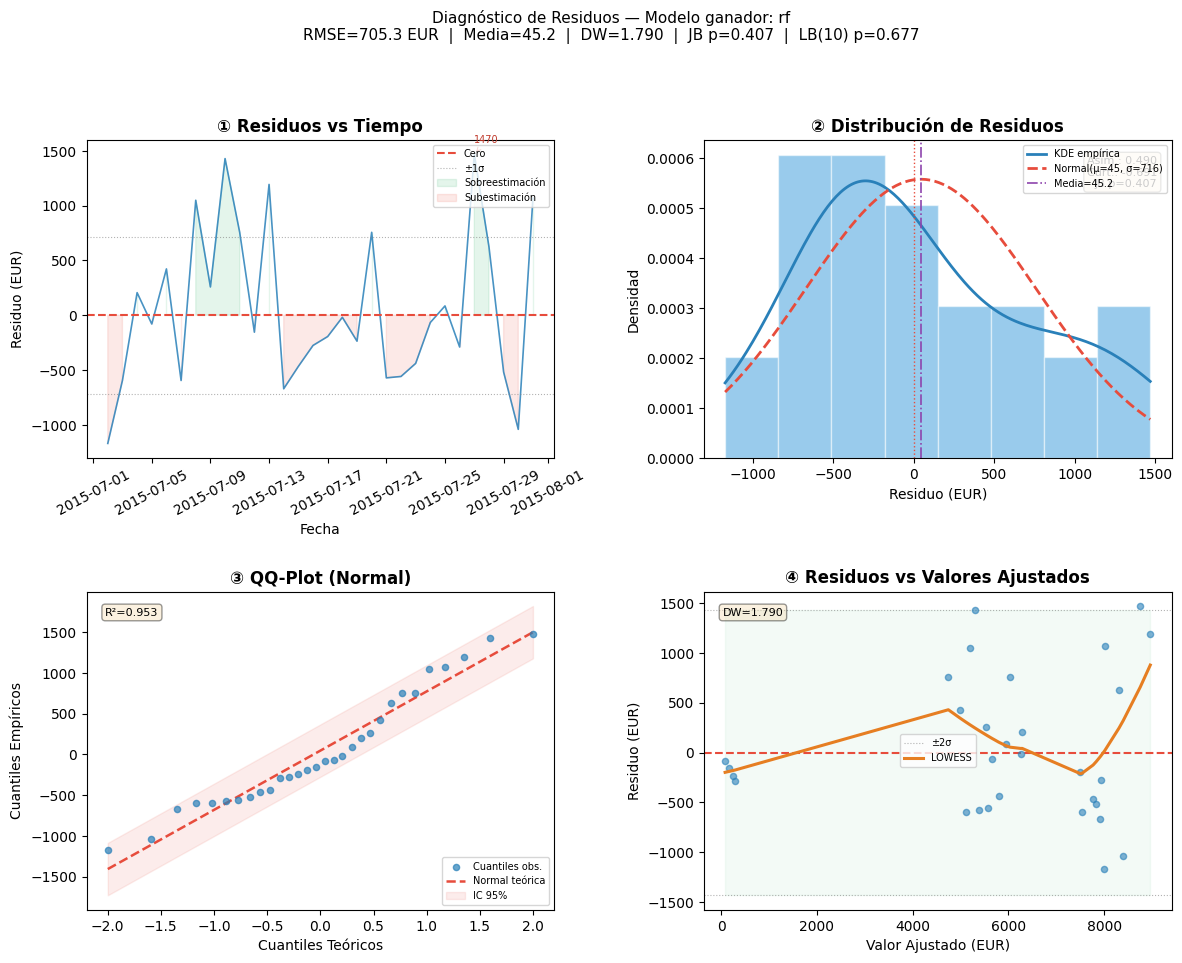


💡 Lectura rápida:
   ① Sin estructura → residuos son ruido puro ✓
   ② Campana en 0  → aproximadamente normales ✓
   ③ Puntos en diagonal → normalidad confirmada ✓
   ④ Nube horizontal sin embudo → varianza constante ✓


In [29]:
import matplotlib.gridspec as gridspec
from statsmodels.nonparametric.smoothers_lowess import lowess

resid_arr = resid_g.values
yhat_arr  = yhat_g.values
fecha_arr = test_results['ds'].loc[yhat_g.index].values

fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    f'Diagnóstico de Residuos — Modelo ganador: {ganador}\n'
    f'RMSE={rmse_scores[ganador]:.1f} EUR  |  '
    f'Media={media_r:.1f}  |  '
    f'DW={dw_stat:.3f}  |  '
    f'JB p={jb_p:.3f}  |  '
    f'LB(10) p={lb_p10:.3f}',
    fontsize=11, y=1.01
)
gs = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.32)

# ── ① Residuos vs Tiempo ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(fecha_arr, resid_arr, color='#2980b9', lw=1.2, alpha=0.85)
ax1.axhline(0,       color='#e74c3c', lw=1.5, ls='--', label='Cero')
ax1.axhline( std_r,  color='gray',    lw=0.8, ls=':',  alpha=0.6, label='±1σ')
ax1.axhline(-std_r,  color='gray',    lw=0.8, ls=':',  alpha=0.6)
ax1.fill_between(fecha_arr, resid_arr, 0,
    where=(resid_arr > 0), alpha=0.12, color='#27ae60', label='Sobreestimación')
ax1.fill_between(fecha_arr, resid_arr, 0,
    where=(resid_arr < 0), alpha=0.12, color='#e74c3c', label='Subestimación')
# Anotar outliers > 2σ
mask_out = np.abs(resid_arr) > 2 * std_r
for fd, rv in zip(fecha_arr[mask_out], resid_arr[mask_out]):
    ax1.annotate(f'{rv:.0f}', xy=(fd, rv), xytext=(0, 8 if rv>0 else -14),
                 textcoords='offset points', fontsize=7, color='#c0392b',
                 arrowprops=dict(arrowstyle='->', color='#c0392b', lw=0.7))
ax1.set_title('① Residuos vs Tiempo', fontweight='bold')
ax1.set_xlabel('Fecha'); ax1.set_ylabel('Residuo (EUR)')
ax1.legend(fontsize=7, loc='upper right')
ax1.tick_params(axis='x', rotation=28)

# ── ② Histograma + KDE ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
n_bins = max(8, len(resid_arr) // 4)
ax2.hist(resid_arr, bins=n_bins, density=True,
         color='#3498db', alpha=0.50, edgecolor='white')
kde_x  = np.linspace(resid_arr.min(), resid_arr.max(), 200)
kde_fn = scipy_stats.gaussian_kde(resid_arr)
ax2.plot(kde_x, kde_fn(kde_x), color='#2980b9', lw=2, label='KDE empírica')
ax2.plot(kde_x, scipy_stats.norm.pdf(kde_x, media_r, std_r),
         color='#e74c3c', lw=2, ls='--',
         label=f'Normal(μ={media_r:.0f}, σ={std_r:.0f})')
ax2.axvline(0,       color='#e74c3c', lw=1.0, ls=':')
ax2.axvline(media_r, color='#8e44ad', lw=1.2, ls='-.', label=f'Media={media_r:.1f}')
ax2.text(0.97, 0.95,
         f'Asim.: {skew_r:.3f}\nCurt.: {kurt_r:.3f}\nJB p={jb_p:.3f}',
         transform=ax2.transAxes, fontsize=8, va='top', ha='right',
         bbox=dict(boxstyle='round', fc='wheat', alpha=0.4))
ax2.set_title('② Distribución de Residuos', fontweight='bold')
ax2.set_xlabel('Residuo (EUR)'); ax2.set_ylabel('Densidad')
ax2.legend(fontsize=7)

# ── ③ QQ-Plot ────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
(osm, osr), (slope, intercept, r_val) = scipy_stats.probplot(resid_arr, dist='norm')
ax3.scatter(osm, osr, color='#2980b9', s=20, alpha=0.70, zorder=3, label='Cuantiles obs.')
line_x = np.array([osm.min(), osm.max()])
ax3.plot(line_x, slope*line_x + intercept,
         color='#e74c3c', lw=1.8, ls='--', label='Normal teórica')
# Banda de confianza aproximada
ci = 1.96 * std_r / np.sqrt(len(resid_arr)) * np.sqrt(np.pi/2)
ax3.fill_between(line_x, slope*line_x+intercept-ci, slope*line_x+intercept+ci,
                 alpha=0.10, color='#e74c3c', label='IC 95%')
ax3.text(0.04, 0.95, f'R²={r_val**2:.3f}',
         transform=ax3.transAxes, fontsize=8, va='top',
         bbox=dict(boxstyle='round', fc='wheat', alpha=0.4))
ax3.set_title('③ QQ-Plot (Normal)', fontweight='bold')
ax3.set_xlabel('Cuantiles Teóricos'); ax3.set_ylabel('Cuantiles Empíricos')
ax3.legend(fontsize=7)

# ── ④ Residuos vs Ajustados ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(yhat_arr, resid_arr, color='#2980b9', s=20, alpha=0.60, zorder=3)
ax4.axhline(0,        color='#e74c3c', lw=1.5, ls='--')
ax4.axhline( 2*std_r, color='gray',    lw=0.8, ls=':',  alpha=0.6)
ax4.axhline(-2*std_r, color='gray',    lw=0.8, ls=':',  alpha=0.6, label='±2σ')
# LOWESS: detecta heterocedasticidad
orden  = np.argsort(yhat_arr)
lw_out = lowess(resid_arr[orden], yhat_arr[orden], frac=0.6)
ax4.plot(lw_out[:,0], lw_out[:,1], color='#e67e22', lw=2.2, label='LOWESS', zorder=4)
ax4.fill_between([yhat_arr.min(), yhat_arr.max()], -2*std_r, 2*std_r,
                 alpha=0.05, color='#27ae60')
ax4.text(0.04, 0.95,
         f'DW={dw_stat:.3f}',
         transform=ax4.transAxes, fontsize=8, va='top',
         bbox=dict(boxstyle='round', fc='wheat', alpha=0.4))
ax4.set_title('④ Residuos vs Valores Ajustados', fontweight='bold')
ax4.set_xlabel('Valor Ajustado (EUR)'); ax4.set_ylabel('Residuo (EUR)')
ax4.legend(fontsize=7)

plt.tight_layout()
plt.savefig('residuos_ganador.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💡 Lectura rápida:')
print('   ① Sin estructura → residuos son ruido puro ✓')
print('   ② Campana en 0  → aproximadamente normales ✓')
print('   ③ Puntos en diagonal → normalidad confirmada ✓')
print('   ④ Nube horizontal sin embudo → varianza constante ✓')


---
## PARTE 12: SHAP — INTERPRETABILIDAD CON MLFORECAST

**Pregunta que responde SHAP:** ¿por qué el modelo dio *esa* predicción en *ese* día concreto?

$$\hat{y}_t = \phi_0 + \sum_{i=1}^{p} \phi_i$$

Donde $\phi_0$ es el valor base (media del dataset) y $\phi_i$ es la contribución de la feature $i$ a esa predicción.

**Flujo correcto con MLForecast** (documentación oficial Nixtla):  
1. `fcst.preprocess(df)` → genera el mismo dataset de features que usó el modelo durante el entrenamiento  
2. `shap.TreeExplainer(fcst.models_['xgb'])` → explainer exacto y eficiente para XGBoost/LightGBM  
3. `shap.plots.*` → visualizaciones

In [30]:
# Paso 1: extraer el dataset de features usando el mismo pipeline del modelo entrenado
# static_features=[] → Open, Promo y Fourier son features dinámicas
prep = fcst_boost.preprocess(df_train, static_features=[])
X    = prep.drop(columns=['unique_id', 'ds', 'y'])  # conservar TODAS las features: lags, rolling, month, Fourier, Open, Promo

print(f'Dataset de features extraído con preprocess():')
print(f'  Dimensiones: {X.shape}')
print(f'  Features: {list(X.columns)}')

Dataset de features extraído con preprocess():
  Dimensiones: (871, 15)
  Features: ['Open', 'Promo', 'sin1_7', 'sin2_7', 'cos1_7', 'cos2_7', 'lag1', 'lag7', 'lag14', 'lag28', 'rolling_mean_lag1_window_size7', 'rolling_std_lag1_window_size7', 'rolling_mean_lag7_window_size28', 'expanding_mean_lag28', 'month']


In [31]:
# Paso 2: SHAP para XGBoost — TreeExplainer es el método exacto y rápido para modelos de árbol
explainer_xgb  = shap.TreeExplainer(fcst_boost.models_['xgb'])
shap_values_xgb = explainer_xgb(X)
print(f'✅ SHAP values calculados para XGBoost. Shape: {shap_values_xgb.shape}')

✅ SHAP values calculados para XGBoost. Shape: (871, 15)


📊 SHAP Beeswarm — Importancia global de features (XGBoost):
  Rojo = valor alto de la feature aumenta la predicción
  Azul = valor bajo de la feature baja la predicción


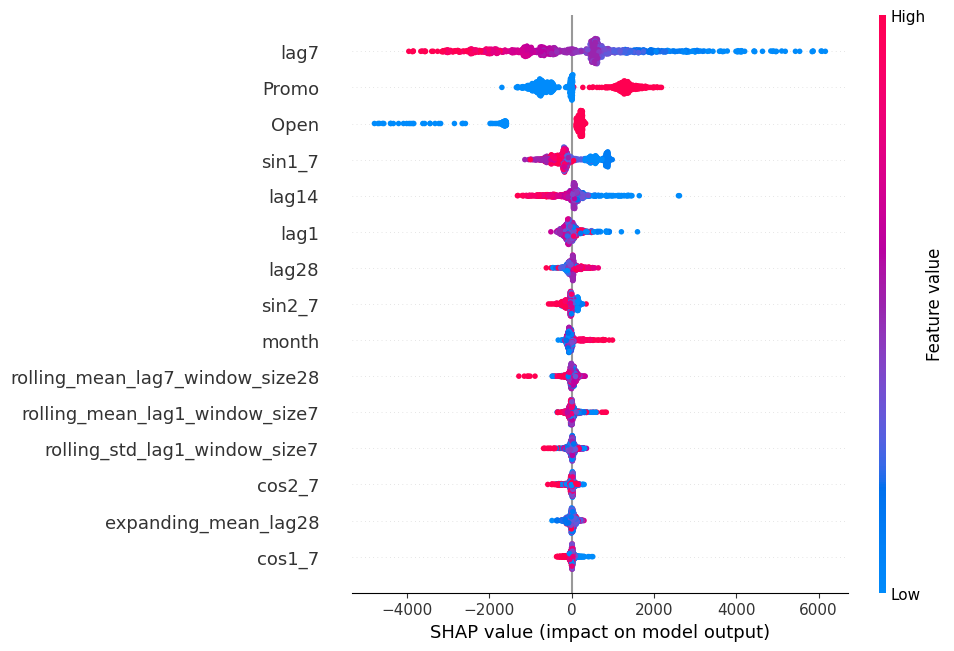

In [32]:
# Importancia global: beeswarm plot
# Muestra distribución de impacto de cada feature sobre TODAS las predicciones
print('📊 SHAP Beeswarm — Importancia global de features (XGBoost):')
print('  Rojo = valor alto de la feature aumenta la predicción')
print('  Azul = valor bajo de la feature baja la predicción')
shap.plots.beeswarm(shap_values_xgb, max_display=15)

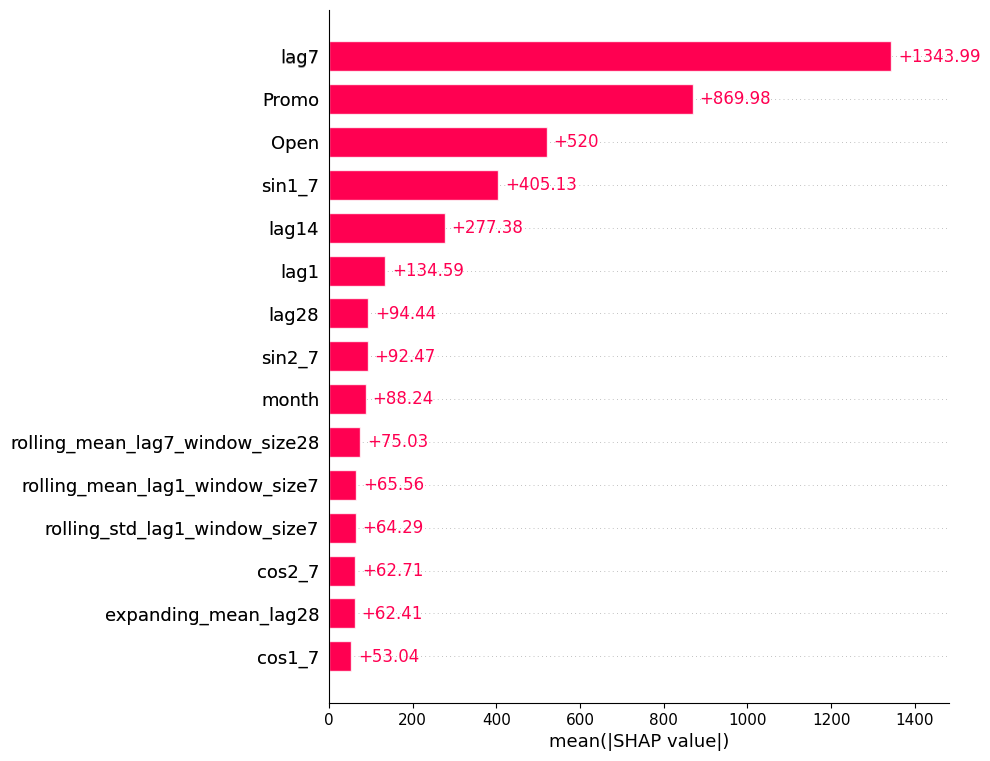

In [33]:
# Importancia global en forma de barras (equivale a feature importance pero con escala SHAP)
shap.plots.bar(shap_values_xgb, max_display=15)

🔍 Predicción individual — fila 10:
   Fecha:       2013-02-21
   Predicción:  1556 EUR


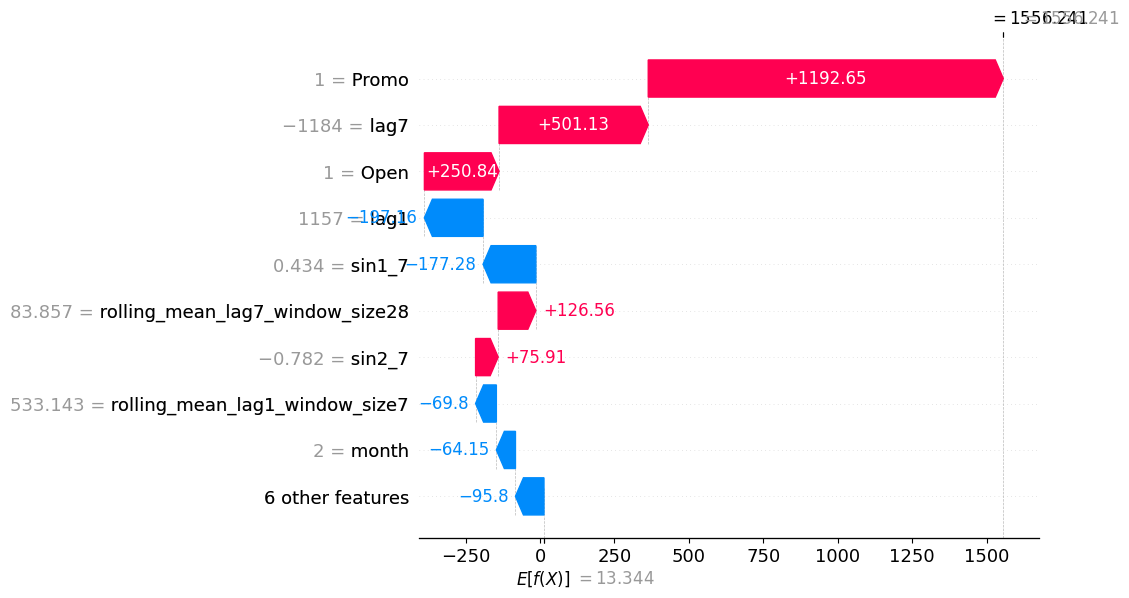

In [34]:
# Explicación de una predicción individual — waterfall plot
# Elige un día específico: el primer lunes del período de test
idx_ejemplo = 10  # puedes cambiar este índice

print(f'🔍 Predicción individual — fila {idx_ejemplo}:')
print(f'   Fecha:       {prep.iloc[idx_ejemplo].ds.date()}')
print(f'   Predicción:  {fcst_boost.models_["xgb"].predict(X.iloc[[idx_ejemplo]])[0]:.0f} EUR')
shap.plots.waterfall(shap_values_xgb[idx_ejemplo])

📊 SHAP Beeswarm — Importancia global de features (LightGBM):


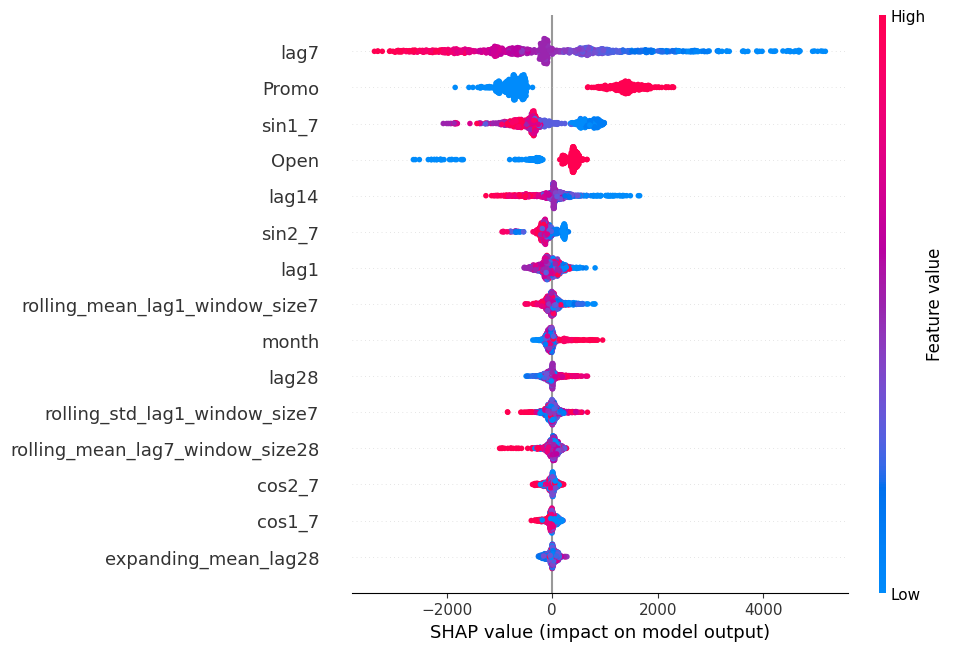

In [35]:
# SHAP para LightGBM — mismo flujo, distinto modelo
explainer_lgbm   = shap.TreeExplainer(fcst_boost.models_['lgbm'])
shap_values_lgbm = explainer_lgbm(X)

print('📊 SHAP Beeswarm — Importancia global de features (LightGBM):')
shap.plots.beeswarm(shap_values_lgbm, max_display=15)

In [36]:
# Comparativa: qué features prioriza cada modelo
imp_xgb  = pd.Series(np.abs(shap_values_xgb.values).mean(0),  index=X.columns).sort_values(ascending=False)
imp_lgbm = pd.Series(np.abs(shap_values_lgbm.values).mean(0), index=X.columns).sort_values(ascending=False)

comp = pd.DataFrame({'XGBoost': imp_xgb, 'LightGBM': imp_lgbm}).round(2)
print('📋 Importancia SHAP media (|φ|) — Top 10 features:')
display(comp.head(10))

fig = go.Figure()
for model, col in [('XGBoost','#e67e22'), ('LightGBM','#27ae60')]:
    vals = comp[model].head(10)
    fig.add_trace(go.Bar(x=vals.index, y=vals.values, name=model,
                         marker_color=col, opacity=0.8))
fig.update_layout(
    title='Importancia SHAP: XGBoost vs LightGBM',
    xaxis_title='Feature', yaxis_title='|SHAP| medio',
    barmode='group', template='plotly_white', height=400
)
fig.show()

📋 Importancia SHAP media (|φ|) — Top 10 features:


,XGBoost,LightGBM
Open,520.000000,433.60
Promo,869.979980,1014.96
cos1_7,53.040001,62.99
cos2_7,62.709999,65.64
expanding_mean_lag28,62.410000,60.24
lag1,134.589996,141.87
lag14,277.380005,267.29
lag28,94.440002,94.97
lag7,1343.989990,1220.85
month,88.239998,95.61


✅ SHAP en predicción: features shape = (14, 15)


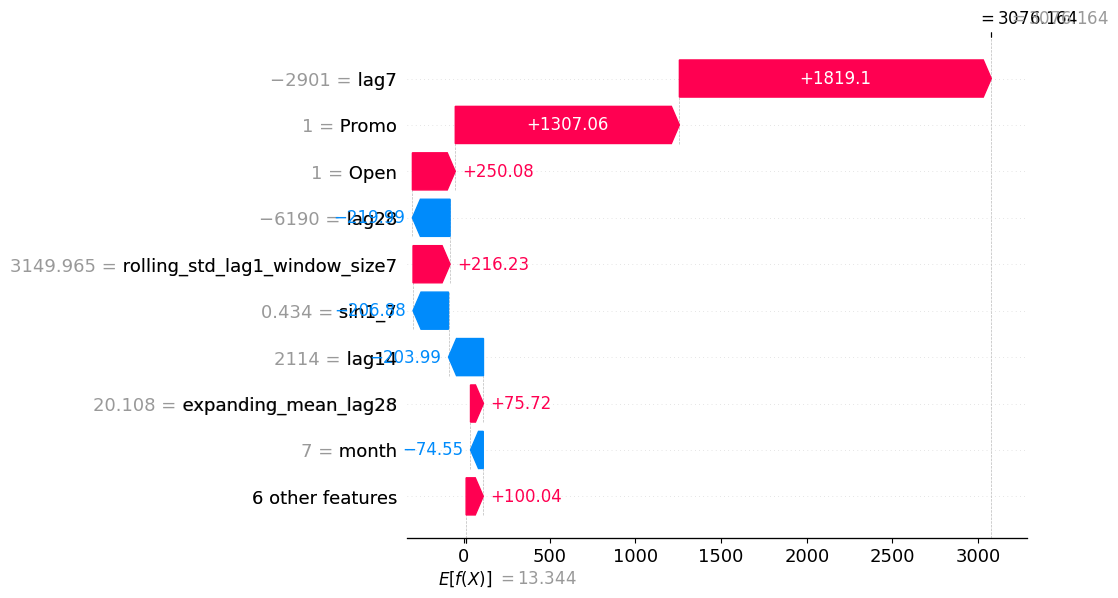

💡 Este waterfall explica la predicción del PRIMER día del horizonte.


In [37]:
# SHAP en tiempo de predicción — usando SaveFeatures callback
# Esto permite explicar las predicciones del futuro, no solo del entrenamiento
from mlforecast.callbacks import SaveFeatures

save_feats = SaveFeatures()
preds_shap = fcst_boost.predict(h=7, X_df=X_test_exo.head(7),
                                  before_predict_callback=save_feats)
X_pred = save_feats.get_features()

shap_pred = explainer_xgb(X_pred)
print(f'✅ SHAP en predicción: features shape = {X_pred.shape}')
shap.plots.waterfall(shap_pred[0])
print('💡 Este waterfall explica la predicción del PRIMER día del horizonte.')

---
## PARTE 13: [AVANZADO] AutoMLForecast + Optuna

En producción, la búsqueda manual de hiperparámetros no escala.  
`AutoMLForecast` integra **Optuna** para optimización bayesiana automática de hiperparámetros,
respetando el forward-chaining en la validación.

> ⚠️ Esta parte es computacionalmente costosa. Se recomienda ejecutar con `num_samples=5` en clase
> y aumentar a 30-50 en casa para resultados más robustos.

In [38]:
import optuna
from mlforecast.auto import (
    AutoMLForecast, AutoLightGBM, AutoXGBoost,
    AutoRandomForest, AutoLinearRegression
)
optuna.logging.set_verbosity(optuna.logging.ERROR)

# Configuración de features (igual que el resto del notebook)
def init_config(trial):
    # Los términos Fourier (sin1_7, cos1_7, sin2_7, cos2_7) están en df_train como
    # columnas exógenas dinámicas — MLForecast los incorpora automáticamente
    # porque fit_config retorna static_features=[].
    # No es necesario incluirlos en date_features.
    return {
        'lags':              [1,7,14,28],  # reducido para acelerar el tuning
        'date_features':     ['month'],           # Fourier viene del DataFrame
        'target_transforms': [Differences([7])],
        'lag_transforms':    {1: [RollingMean(window_size=7)]},
    }

def fit_config(trial):
    return {'static_features': []}

# Espacios de búsqueda de hiperparámetros
def lgbm_config(trial):
    return {
        'learning_rate':  trial.suggest_float('learning_rate', 1e-4, 0.1, log=True),
        'num_leaves':     trial.suggest_int('num_leaves', 2, 128, log=True),
        'n_estimators':   trial.suggest_int('n_estimators', 100, 1000, step=50),
        'reg_alpha':      trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':     trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'objective':      'regression',
    }

def xgb_config(trial):
    return {
        'learning_rate':  trial.suggest_float('learning_rate', 1e-4, 0.5, log=True),
        'max_depth':      trial.suggest_int('max_depth', 1, 10),
        'n_estimators':   trial.suggest_int('n_estimators', 100, 1000, step=50),
        'reg_alpha':      trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':     trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'objective':      'reg:squarederror',
    }

auto_mlf = AutoMLForecast(
    models={
        'LightGBM_auto': AutoLightGBM(config=lgbm_config),
        'XGBoost_auto':  AutoXGBoost(config=xgb_config),
        'RF_auto':       AutoRandomForest(),
        'LR_auto':       AutoLinearRegression(),
    },
    freq='D',
    season_length=7,
    init_config=init_config,
    fit_config=fit_config,
)

print('✅ AutoMLForecast configurado')
print('   Ejecutando optimización con num_samples=5 (aumentar para producción)...')

auto_mlf.fit(df_train, n_windows=5, h=7, step_size=1, num_samples=10)
print('✅ AutoMLForecast entrenado')

✅ AutoMLForecast configurado
   Ejecutando optimización con num_samples=5 (aumentar para producción)...
✅ AutoMLForecast entrenado


In [39]:
# Mejores hiperparámetros encontrados
for nombre in ['LightGBM_auto', 'XGBoost_auto','RF_auto']:
    best = auto_mlf.results_[nombre].best_trial.user_attrs['config']
    print(f'\n🏆 Mejores hiperparámetros — {nombre}:')
    for k, v in best.items():
        print(f'   {k}: {v}')


🏆 Mejores hiperparámetros — LightGBM_auto:
   model_params: {'learning_rate': 0.008313101133778738, 'num_leaves': 3, 'n_estimators': 950, 'reg_alpha': 0.040666950653938445, 'reg_lambda': 0.011838854959491772, 'objective': 'regression'}
   mlf_init_params: {'lags': [1, 7, 14, 28], 'date_features': ['month'], 'target_transforms': [<mlforecast.target_transforms.Differences object at 0x73c7404a6040>], 'lag_transforms': {1: [RollingMean(window_size=7)]}, 'num_threads': 1}
   mlf_fit_params: {'static_features': []}

🏆 Mejores hiperparámetros — XGBoost_auto:
   model_params: {'learning_rate': 0.01285703275549322, 'max_depth': 5, 'n_estimators': 1000, 'reg_alpha': 0.0003237606428745277, 'reg_lambda': 0.0011076021254597269, 'objective': 'reg:squarederror'}
   mlf_init_params: {'lags': [1, 7, 14, 28], 'date_features': ['month'], 'target_transforms': [<mlforecast.target_transforms.Differences object at 0x73c7404a4910>], 'lag_transforms': {1: [RollingMean(window_size=7)]}, 'num_threads': 1}
   ml

In [40]:
# Pronósticos con modelos auto-tuneados
preds_auto = auto_mlf.predict(h=HORIZONTE, X_df=X_test_exo)
test_auto  = df_test.merge(preds_auto, on=['unique_id','ds'], how='left')

auto_cols = [c for c in preds_auto.columns if c not in ['unique_id','ds']]
test_auto[auto_cols] = test_auto[auto_cols].clip(lower=0)

eval_auto = evaluate(test_auto, models=auto_cols, metrics=METRICAS, target_col='y')
print('📊 Evaluación AutoMLForecast sobre Test:')
display(eval_auto.style.background_gradient(cmap='RdYlGn_r', axis=1))

📊 Evaluación AutoMLForecast sobre Test:


,unique_id,metric,LightGBM_auto,XGBoost_auto,RF_auto,LR_auto
0,746,mae,548.899870,610.485069,516.264274,609.525203
1,746,rmse,689.755726,780.524030,637.972972,728.998876
2,746,mape,0.090802,0.106979,0.087293,0.101376


In [41]:
# Visualización pronósticos vs real
fig = go.Figure()
# Serie de train (contexto)
fig.add_trace(go.Scatter(x=df_train.tail(90).ds, y=df_train.tail(90).y,
                         name='Train (últimos 90d)', line=dict(color='#95a5a6', width=1)))
# Real test
fig.add_trace(go.Scatter(x=test_auto.ds, y=test_auto.y,
                         name='Real', line=dict(color='#000000', width=3)))
# Predicciones seleccionadas
for col, color in zip(['LightGBM_auto','XGBoost_auto','RF_auto','LR_auto'],
                       ['#e74c3c','#9b59b6','#e67e22','#27ae60','#3498db']):
    if col in test_auto.columns:
        fig.add_trace(go.Scatter(x=test_auto.ds, y=test_auto[col],
                                 name=col, line=dict(color=color, width=1.5)))

# Fix: Usamos add_shape para evitar el bug de add_vline con Timestamps
fig.add_shape(type='line',
              x0=cutoff_dt, x1=cutoff_dt,
              y0=0, y1=1, yref='paper',
              line=dict(color='gray', dash='dash'))

# Agregamos la anotación manualmente
fig.add_annotation(x=cutoff_dt, y=1, yref='paper',
                   text='inicio test', showarrow=False, yshift=10)

fig.update_layout(
    title='Pronósticos sobre Test — Rossmann Tienda 746',
    xaxis_title='Fecha', yaxis_title='Ventas (EUR)',
    hovermode='x unified', height=480, template='plotly_white'
)
fig.show()

---
## RESUMEN FINAL

| Concepto | Qué practicamos |
|---|---|
| **Windowing** | `MLForecast.preprocess()` muestra exactamente qué features se generan |
| **Feature engineering** | Lags, rolling stats, Fourier cíclico (reemplaza dayofweek), exógenas (Open, Promo) |
| **Gradient Boosting** | Aprendizaje secuencial de residuos respetando el orden temporal |
| **XGBoost** | Regularización explícita ($\gamma, \lambda, \alpha$) dentro de MLForecast |
| **LightGBM** | Leaf-wise + GOSS + EFB dentro de MLForecast |
| **Validación** | Forward-chaining con `cross_validation()` + `evaluate()` |
| **SHAP** | `preprocess()` + `TreeExplainer` + waterfall/beeswarm/bar plots |
| **Diagnóstico** | Tests JB, Ljung-Box, Durbin-Watson, Breusch-Pagan sobre residuos |
| **AutoMLForecast** | Optuna integrado para tuning automático en producción |


Todo el feature engineering de esta semana fue **manual**: decidimos nosotros qué lags, qué ventanas, qué transformaciones.  
**¿Y si el modelo aprendiera sus propias representaciones temporales?**  
→ Redes Neuronales, MLPs, **N-BEATS** y **N-HiTS** con `NeuralForecast`.